<a href="https://colab.research.google.com/github/asta3002/FISH/blob/main/Custom_TensorNEAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Installation

In [24]:
!pip install git+https://github.com/EMI-Group/tensorneat.git

  Cloning https://github.com/EMI-Group/tensorneat.git to /tmp/pip-req-build-uvg3ipof
  Running command git clone --filter=blob:none --quiet https://github.com/EMI-Group/tensorneat.git /tmp/pip-req-build-uvg3ipof
  Resolved https://github.com/EMI-Group/tensorneat.git to commit b9778dcf8b2db5f3698b3965073c2181608c467c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [25]:
!pip install -U "jax[tpu]==0.4.28"

  Using cached jax-0.4.28-py3-none-any.whl.metadata (23 kB)
  Using cached jaxlib-0.4.28-cp312-cp312-manylinux2014_x86_64.whl.metadata (1.8 kB)
INFO: pip is looking at multiple versions of jax[tpu] to determine which version is compatible with other requirements. This could take a while.
ERROR: Ignored the following yanked versions: 0.0.1
ERROR: Could not find a version that satisfies the requirement libtpu-nightly==0.1.dev20240508; extra == "tpu" (from jax[tpu]) (from versions: none)
ERROR: No matching distribution found for libtpu-nightly==0.1.dev20240508; extra == "tpu"


In [26]:
!pip install evojax

#Libraries

In [27]:
# Import necessary modules
import jax
import jax.numpy as jnp
import argparse
import os
from jax import random
from evojax.task.slimevolley import SlimeVolley
from tensorneat.problem import BaseProblem
from tensorneat.pipeline import Pipeline
from tensorneat.algorithm.neat import NEAT
from tensorneat.genome import DefaultGenome, BiasNode, DefaultConn,DefaultMutation
from tensorneat.genome.operations import DefaultCrossover, DefaultDistance, DefaultMutation
from tensorneat.common import ACT, AGG
from typing import Tuple
from functools import partial

#DEMO

In [ ]:
max_steps = 3000
task = SlimeVolley(test=True, max_steps=max_steps)
task_reset_fn = jax.jit(task.reset)
task_step_fn = jax.jit(task.step)
og_key = jax.random.PRNGKey(12346)[None,:]
task_state = task_reset_fn(og_key)
test_state = task.reset(og_key)
# dummy_action = jnp.array([[0.0, 1.0, -1.0]], dtype=jnp.float32)  # shape [1, 3]
# # next_state,reward,done = task_step_fn(task_state,dummy_action)
# # action = (network_output > 0.0).astype(jnp.int32)


In [ ]:
print(test_state)

State(game_state=GameState(ball=ParticleState(x=Array([0.], dtype=float32), y=Array([12.], dtype=float32), prev_x=Array([0.], dtype=float32), prev_y=Array([12.], dtype=float32), vx=Array([6.860523], dtype=float32), vy=Array([20.072697], dtype=float32), r=Array([0.5], dtype=float32)), agent_left=AgentState(direction=Array([-1], dtype=int32, weak_type=True), x=Array([-12.], dtype=float32, weak_type=True), y=Array([1.5], dtype=float32, weak_type=True), r=Array([1.5], dtype=float32, weak_type=True), vx=Array([0], dtype=int32, weak_type=True), vy=Array([0], dtype=int32, weak_type=True), desired_vx=Array([0], dtype=int32, weak_type=True), desired_vy=Array([0], dtype=int32, weak_type=True), life=Array([5], dtype=int32, weak_type=True)), agent_right=AgentState(direction=Array([1], dtype=int32, weak_type=True), x=Array([12.], dtype=float32, weak_type=True), y=Array([1.5], dtype=float32, weak_type=True), r=Array([1.5], dtype=float32, weak_type=True), vx=Array([0], dtype=int32, weak_type=True), v

In [ ]:
def squeeze_state(state):
        return jax.tree_util.tree_map(lambda x: jnp.squeeze(x, axis=0) if hasattr(x, "ndim") and x.ndim > 0 else x, state)

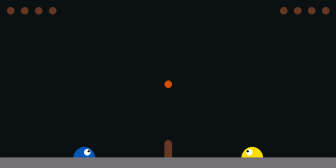

In [ ]:
# task.render(squeeze_state(test_state))

In [ ]:
print(task_state.obs)

[[1.2       0.15      0.        0.        0.        1.2       0.6860523
  2.0072696 1.2       0.15      0.        0.       ]]


In [ ]:
print(task_state.game_state.agent_left)

AgentState(direction=Array([-1], dtype=int32, weak_type=True), x=Array([-12.], dtype=float32, weak_type=True), y=Array([1.5], dtype=float32, weak_type=True), r=Array([1.5], dtype=float32, weak_type=True), vx=Array([0], dtype=int32, weak_type=True), vy=Array([0], dtype=int32, weak_type=True), desired_vx=Array([0], dtype=int32, weak_type=True), desired_vy=Array([0], dtype=int32, weak_type=True), life=Array([5], dtype=int32, weak_type=True))


In [ ]:
print(task_state.game_state.agent_right)

AgentState(direction=Array([1], dtype=int32, weak_type=True), x=Array([12.], dtype=float32, weak_type=True), y=Array([1.5], dtype=float32, weak_type=True), r=Array([1.5], dtype=float32, weak_type=True), vx=Array([0], dtype=int32, weak_type=True), vy=Array([0], dtype=int32, weak_type=True), desired_vx=Array([0], dtype=int32, weak_type=True), desired_vy=Array([0], dtype=int32, weak_type=True), life=Array([5], dtype=int32, weak_type=True))


In [ ]:
print(task_state.game_state.ball)

ParticleState(x=Array([0.], dtype=float32), y=Array([12.], dtype=float32), prev_x=Array([0.], dtype=float32), prev_y=Array([12.], dtype=float32), vx=Array([6.860523], dtype=float32), vy=Array([20.072697], dtype=float32), r=Array([0.5], dtype=float32))


In [ ]:
# print(task_state.game_state.agent_left.life,task_state.game_state.agent_right.life)

[5] [5]


In [ ]:
# next_state = task_state

In [ ]:
# total_reward = jnp.array(0.0, dtype=jnp.float32)

In [ ]:
# for i in range(3000):
#   next_state,reward,done = task_step_fn(next_state,dummy_action)
#   reward = jnp.squeeze(reward).astype(jnp.float32)
#   if(reward):
#     print(reward,done,next_state.game_state.agent_left.life,next_state.game_state.agent_right.life)
#   total_reward = total_reward + reward
#   if done:
#     break




-1.0 [False] [5] [4]
-1.0 [False] [5] [3]
1.0 [False] [4] [3]
-1.0 [False] [4] [2]
-1.0 [False] [4] [1]
-1.0 [False] [4] [0]
-1.0 [False] [4] [-1]
-1.0 [False] [4] [-2]
-1.0 [False] [4] [-3]
-1.0 [False] [4] [-4]
-1.0 [False] [4] [-5]
-1.0 [False] [4] [-6]
-1.0 [False] [4] [-7]
-1.0 [False] [4] [-8]
-1.0 [False] [4] [-9]
-1.0 [False] [4] [-10]
-1.0 [False] [4] [-11]
-1.0 [False] [4] [-12]
-1.0 [False] [4] [-13]
-1.0 [False] [4] [-14]
-1.0 [False] [4] [-15]
-1.0 [False] [4] [-16]
-1.0 [False] [4] [-17]
-1.0 [False] [4] [-18]
-1.0 [False] [4] [-19]
-1.0 [False] [4] [-20]
-1.0 [False] [4] [-21]
-1.0 [False] [4] [-22]
-1.0 [False] [4] [-23]
-1.0 [False] [4] [-24]
-1.0 [False] [4] [-25]
-1.0 [False] [4] [-26]
-1.0 [False] [4] [-27]


In [ ]:
# print(total_reward)

-31.0


In [ ]:
# print(task_state.game_state)
# print(task_state.obs)

GameState(ball=ParticleState(x=Array([0.], dtype=float32), y=Array([12.], dtype=float32), prev_x=Array([0.], dtype=float32), prev_y=Array([12.], dtype=float32), vx=Array([6.860523], dtype=float32), vy=Array([20.072697], dtype=float32), r=Array([0.5], dtype=float32)), agent_left=AgentState(direction=Array([-1], dtype=int32, weak_type=True), x=Array([-12.], dtype=float32, weak_type=True), y=Array([1.5], dtype=float32, weak_type=True), r=Array([1.5], dtype=float32, weak_type=True), vx=Array([0], dtype=int32, weak_type=True), vy=Array([0], dtype=int32, weak_type=True), desired_vx=Array([0], dtype=int32, weak_type=True), desired_vy=Array([0], dtype=int32, weak_type=True), life=Array([5], dtype=int32, weak_type=True)), agent_right=AgentState(direction=Array([1], dtype=int32, weak_type=True), x=Array([12.], dtype=float32, weak_type=True), y=Array([1.5], dtype=float32, weak_type=True), r=Array([1.5], dtype=float32, weak_type=True), vx=Array([0], dtype=int32, weak_type=True), vy=Array([0], dtyp

#SlimeVolleyBall Environment

In [28]:
import jax.numpy as jnp

def adjusted_fitness(s_fitness):
    """
    Calculates the total adjusted fitness for a species, as described in the original NEAT paper.

    Args:
        s_fitness (jnp.ndarray): A JAX array containing the fitness values of individuals
                                 in a single species. Non-members are represented by -jnp.inf.

    Returns:
        jnp.ndarray: The total adjusted fitness of the species.
    """
    # 1. Create a boolean mask to identify valid fitness values (i.e., not -jnp.inf)
    is_member_mask = jnp.isfinite(s_fitness)

    # 2. Count the number of members in the species
    species_size = jnp.sum(is_member_mask)

    # Use a conditional to handle the case of an empty species (size=0) to avoid division by zero.
    species_size = jnp.where(species_size == 0, 1, species_size)

    # 3. Adjust the fitness of each member by dividing by the species size.
    # The where clause ensures only valid fitnesses are adjusted.
    adjusted_s_fitness = jnp.where(is_member_mask, s_fitness / species_size, 0.0)

    # 4. Sum the adjusted fitness values to get the species' total adjusted fitness.
    total_adjusted_fitness = jnp.sum(adjusted_s_fitness)

    return total_adjusted_fitness

In [33]:
class SlimeVolleyEnv(BaseProblem):
    jitable = True  # Needed for TensorNEAT JIT support

    def __init__(self, max_episode_steps=3000, test=False, num_episodes=3):
        super().__init__()
        self.max_steps = max_episode_steps
        self.episodes = num_episodes

        # Create task instance
        self.task = SlimeVolley(test=True, max_steps=self.max_steps)
        self.test_task = SlimeVolley(test=True, max_steps=3000)

        # JIT compile reset and step functions
        self.task_reset = jax.jit(self.task.reset)
        self.task_step = jax.jit(self.task.step)
        self.test_task_reset = jax.jit(self.test_task.reset)
        self.test_task_step = jax.jit(self.test_task.step)

    def evaluate(self, state, randkey, act_func, params):
        """Evaluate an individual on SlimeVolley."""

        def run_episode(ep_key):
            # Reset environment
            reset_key = ep_key[None, :]
            task_state = self.task_reset(reset_key)

            # Carry: (task_state, total_reward, randkey)
            sum_reward = jnp.array(0.0, dtype=jnp.float32)
            init_carry = (task_state, sum_reward)
            # @jax.jit
            def step_fn(carry, _):
                task_state, total_reward = carry
                # key, step_key = jax.random.split(key)
                # print(task_state)

                # obs = self.task.get_obs(task_state, self.task.params)
                obs  = task_state.obs
                # obs = obs * obs.dtype.type(10)
                obs = obs.squeeze()
                # print(obs.ndim)

                action_out = act_func(task_state, params,obs)


                # Convert output to discrete action (argmax over action space)
                # jax.debug.print("action_out: {}", action_out)
                action = (action_out > 0.0).astype(jnp.float32)
                # jax.debug.print("action_out: {}", action)
                jax_action = action[None,:]
                # jax.debug.print("action_out: {}", jax_action)
                # jax.debug.print("task_state : {}",task_state)
                # jax.debug.print("action_out: {}", jax_action)
                new_state, reward, done = self.task_step(task_state, jax_action)
                reward = jnp.squeeze(reward).astype(jnp.float32)

                reward = jnp.where(reward > 0, reward.dtype.type(20), jnp.where(reward < 0, reward.dtype.type(-22), reward))
                # reward = jnp.where(reward == 0,reward.dtype.type(-0.5),reward)
                total_reward = total_reward + reward

                return (new_state, total_reward), None

            final_carry, _ = jax.lax.scan(step_fn, init_carry, None, length=self.max_steps)
            return final_carry[1]  # total_reward

        # Run multiple episodes and average reward
        ep_keys = jax.random.split(randkey, self.episodes)
        rewards = jax.vmap(run_episode)(ep_keys)
        return jnp.mean(rewards)

    @property
    def input_shape(self):
        return self.task.obs_shape  # Provided by SlimeVolley

    @property
    def output_shape(self):
        return self.task.act_shape  # Provided by SlimeVolley

    def squeeze_state(self,state):
        return jax.tree_util.tree_map(lambda x: jnp.squeeze(x, axis=0) if hasattr(x, "ndim") and x.ndim > 0 else x, state)

    def show(self, state, randkey, act_func, params, *args, **kwargs):

        """Render a few episodes to visually inspect performance."""
        import time
        import numpy as np  # Add numpy import for type conversion
        print("\n" + "="*50)
        print("SLIMEVOLLEY AGENT PERFORMANCE")
        print("="*50)

        best_reward = float('-inf')
        best_screens = []
        best_steps = 0

        # JAX-compiled function for running a single episode
        @jax.jit
        def run_single_episode(episode_key):
            """Run a single episode and return states, rewards, and done flags."""
            test_task_state = self.test_task_reset(episode_key[None, :])

            def step_fn(carry, _):
                task_state, total_reward, step_count, terminated = carry

                # Only process if not terminated
                obs = task_state.obs.squeeze()
                action_out = act_func(task_state, params, obs)
                action = (action_out > 0.0).astype(jnp.float32)
                jax_action = action[None, :]

                new_state, reward, done = self.test_task_step(task_state, jax_action)
                reward = jnp.squeeze(reward).astype(jnp.float32)
                done = jnp.squeeze(done).astype(jnp.bool_)
                # Update only if not already terminated
                new_total_reward = jnp.where(terminated, total_reward, total_reward + reward)
                new_step_count = jnp.where(terminated, step_count, step_count + 1)
                new_terminated = terminated | done

                # Use previous state if already terminated
                final_state = jax.tree_util.tree_map(
                    lambda old, new: jnp.where(terminated, old, new),
                    task_state, new_state
                )

                return (final_state, new_total_reward, new_step_count, new_terminated), {
                    'state': final_state,
                    'reward': reward,
                    'done': done,
                    'terminated': new_terminated
                }

            init_carry = (test_task_state, jnp.array(0.0, dtype=jnp.float32),
                        jnp.array(0, dtype=jnp.int32), jnp.array(False))

            final_carry, history = jax.lax.scan(step_fn, init_carry, None, length=3000)

            return {
                'final_reward': final_carry[1],
                'final_steps': final_carry[2],
                'states': history['state'],
                'rewards': history['reward'],
                'dones': history['done'],
                'terminated_flags': history['terminated']
            }

        # Run episodes using JAX
        episode_keys = jax.random.split(randkey, 3)

        for i in range(3):
            # Run episode with JAX
            episode_result = run_single_episode(episode_keys[i])

            total_reward = float(episode_result['final_reward'])
            final_steps = int(episode_result['final_steps'])
            states = episode_result['states']
            rewards = episode_result['rewards']
            dones = episode_result['dones']
            terminated_flags = episode_result['terminated_flags']

            # Find the actual end of the episode
            done_indices = jnp.where(dones)[0]
            if len(done_indices) > 0:
                actual_end_step = int(done_indices[0]) + 1
                print(f"{done_indices[0]}, {total_reward}, {float(rewards[done_indices[0]])}, "
                      f"{states.game_state.agent_left.life[done_indices[0]]}, "
                      f"{states.game_state.agent_right.life[done_indices[0]]}, {True}")
            else:
                actual_end_step = 3000

            print(f"Episode {i+1} Reward: {total_reward}")

            # Generate screens for this episode (only up to actual end)
            current_screens = []
            for step in range(actual_end_step):
                # Extract state at this step and squeeze it
                step_state = jax.tree_util.tree_map(lambda x: x[step], states)
                render_state = self.squeeze_state(step_state)
                current_screens.append(self.test_task.render(render_state))

            # Check if this is the best episode so far
            if total_reward > best_reward:
                best_reward = total_reward
                best_screens = current_screens.copy()
                best_steps = actual_end_step
            elif total_reward == best_reward:
                if actual_end_step > best_steps:
                    best_reward = total_reward
                    best_screens = current_screens.copy()
                    best_steps = actual_end_step

        print(f"\nBest episode reward: {best_reward}")

        # Create GIF only from the best episode
        log_dir = '/content'
        gif_file = os.path.join(log_dir, 'slimevolley_best.gif')
        if best_screens:
            best_screens[0].save(gif_file, save_all=True, append_images=best_screens[1:],
                                duration=40, loop=0)
            print(f"GIF created from best episode and saved to: {gif_file}")
        else:
            print("No screens to save for GIF")
    # def show(self, state, randkey, act_func, params, *args, **kwargs):

    #     """Render a few episodes to visually inspect performance."""
    #     import time
    #     print("\n" + "="*50)
    #     print("SLIMEVOLLEY AGENT PERFORMANCE")
    #     print("="*50)

    #     best_reward = float('-inf')
    #     best_screens = []
    #     # episode_rewards = []
    #     best_steps = 0

    #     for i in range(3):
    #         key, randkey = jax.random.split(randkey)
    #         test_task_state = self.test_task.reset(key[None, :])
    #         total_reward = jnp.array(0.0, dtype=jnp.float32)
    #         current_screens = []
    #         current_step=0
    #         for step in range(3000):
    #             obs = test_task_state.obs
    #             obs = obs.squeeze()
    #             action_out = act_func(test_task_state, params, obs)

    #             # Convert output to discrete action (argmax over action space)
    #             action = (action_out > 0.0).astype(jnp.float32)
    #             jax_action = action[None, :]

    #             new_state, reward, done = self.test_task.step(test_task_state, jax_action)
    #             render_state = self.squeeze_state(new_state)

    #             # Store screen for current episode
    #             current_screens.append(self.test_task.render(render_state))

    #             test_task_state = new_state
    #             # if reward:
    #             #     print(total_reward, reward, test_task_state.game_state.agent_left.life,test_task_state.game_state.agent_right.life, done)
    #             total_reward = total_reward + reward
    #             current_step+=1
    #             if done:
    #                 print(step,total_reward, reward, test_task_state.game_state.agent_left.life,test_task_state.game_state.agent_right.life, done)
    #                 break

    #         # episode_rewards.append(float(total_reward))
    #         print(f"Episode {i+1} Reward: {total_reward}")

    #         # Check if this is the best episode so far
    #         if total_reward > best_reward:
    #             best_reward = total_reward
    #             best_screens = current_screens.copy()  # Save screens from best episode
    #             best_steps = current_step
    #         elif total_reward == best_reward:
    #               if(current_step> best_steps):
    #                 best_reward = total_reward
    #                 best_screens = current_screens.copy()



    #     print(f"\nBest episode reward: {best_reward}")

    #     # Create GIF only from the best episode
    #     log_dir = '/content'
    #     gif_file = os.path.join(log_dir, 'slimevolley_best.gif')
    #     best_screens[0].save(gif_file, save_all=True, append_images=best_screens[1:],
    #                         duration=40, loop=0)

    #     print(f"GIF created from best episode and saved to: {gif_file}")


#Training

In [34]:
pipeline = Pipeline(
    algorithm=NEAT(
        pop_size=400,  # Larger population for complex task
        species_size=200,  # More species for diversity
        survival_threshold=0.2,  # Top 30% survive
        genome=DefaultGenome(
            num_inputs=12,  # SlimeVolley observation space
            num_outputs=3,  # SlimeVolley action space (3 discrete actions)
            max_nodes=100,
            max_conns=1500,
            init_hidden_layers=(),  # Start with no hidden layers
            node_gene=BiasNode( bias_init_mean= 0.0,
                                bias_init_std = 0.1,
                                bias_mutate_power = 0.05,
                                bias_mutate_rate = 0.1,
                                bias_replace_rate = 0.005,
                                bias_lower_bound = -3,
                                bias_upper_bound = 3,
                                aggregation_default = AGG.sum,
                                aggregation_options = [AGG.sum, AGG.mean, AGG.max,],
                                aggregation_replace_rate = 0.0,
                                activation_default = ACT.relu,
                                activation_options=[
                                                    ACT.relu,
                                                    ACT.sigmoid,
                                                  # ACT.identity,  # Can help with periodic behaviors
                                                  ],
                                activation_replace_rate= 0.05,


                                ),
            conn_gene=DefaultConn(weight_init_mean  = 0.0,
                                  weight_init_std   = 1.0,
                                  weight_mutate_power = 0.2, #scale of perturbation
                                  weight_mutate_rate  = 0.1,  #probability of perturbation
                                  weight_replace_rate = 0.005,
                                  weight_lower_bound = -5,
                                  weight_upper_bound = 5,
                                  ),
            mutation=DefaultMutation(conn_add = 0.3,
                                     conn_delete  = 0.05,
                                     node_add = 0.3,
                                     node_delete = 0.05,
                                     ),
            crossover=DefaultCrossover(),
            distance=DefaultDistance(compatibility_disjoint = 1.0,
                                     compatibility_weight  = 0.4,
                                     ),
            output_transform=ACT.tanh, # Tanh output activation
            input_transform=None,


                        ),

        max_stagnation =  30,
        species_elitism = 4,
        spawn_number_change_rate= 0.5,
        genome_elitism  = 7,
        min_species_size = 1,
        compatibility_threshold = 0.5,
        species_fitness_func = jnp.max, #custom function
        species_number_calculate_by ="rank",
    ),
    problem=SlimeVolleyEnv(
        max_episode_steps=3000,  # Shorter episodes for faster training
        num_episodes=3  # Average over 3 episodes per evaluation
    ),
    generation_limit=540,  # Run for 200 generations
    fitness_target=5.0,  # Stop if this fitness is reached
    seed=42,
)



In [ ]:
state = pipeline.setup()

state, best = pipeline.auto_run(state)

initializing
initializing finished
start compile
compile finished, cost time: 38.916392s
Generation: 1, Cost time: 3451.67ms
 	fitness: valid cnt: 400, max: -571.3334, min: -924.0000, mean: -743.3300, std: 61.0337

	node counts: max: 16, min: 15, mean: 15.30
 	conn counts: max: 38, min: 35, mean: 36.30
 	species: 200, [1, 6, 3, 4, 7, 5, 7, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 164]

Generation: 2, Cost time: 3782.62ms
 	fitness: valid cnt: 400, max: -530.666

In [ ]:
# show result
pipeline.show(state, best)

In [ ]:
github_path = "First/NEAT_JAX/Custom_TensorNEAT.ipynb"